# NLP Challenge: Glassdoor Sentiment Analysis
 **Descripción:** Notebook de exploración, entrenamiento y evaluación de sentimientos.


In [21]:

# 1. Configuración y Carga de Datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de rutas según estructura del proyecto
BASE_DIR = Path.cwd().parent
RAW_DATA = BASE_DIR / "datos" / "raw_data" / "raw_target_data.csv"
df_raw = pd.read_csv(RAW_DATA)
df_raw.head()

,pros,cons
0,Scheduling and time off is decently ok.,Sometimes you will be working by yourself with...
1,NaN,NaN
2,helps develop communication and customer service,standing for long periods of time
3,Buen sueldo acorde a la posicion,Clientes maleducados que siempre quieren todo
4,NaN,NaN


C:\Users\Pavilion\AppData\Local\Temp\ipykernel_18688\1573277074.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Pavilion\AppData\Local\Temp\ipykernel_18688\1573277074.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


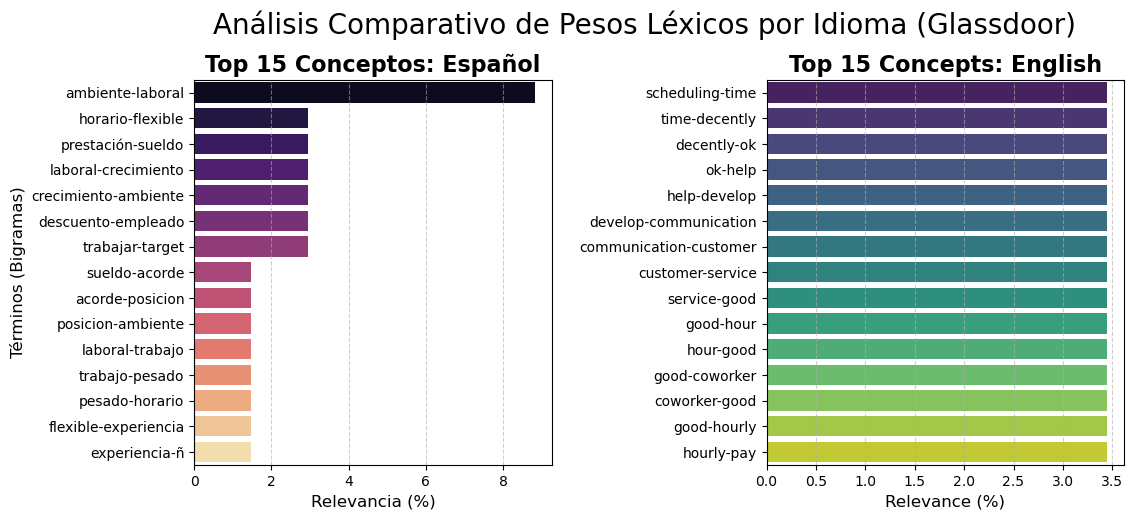

In [22]:

# 2. Comparativa de Conceptos Clave por Idioma
# Visualizamos los 15 bigramas más frecuentes en ambos idiomas para identificar patrones de satisfacción o queja en diferentes regiones.

# Configuración de rutas
CLEAN_DATA_DIR = Path.cwd().parent / "datos" / "clean_data"
es_stats_path = CLEAN_DATA_DIR / "stats_spanish_2gram.csv"
en_stats_path = CLEAN_DATA_DIR / "stats_english_2gram.csv"

# Verificación y Carga
if es_stats_path.exists() and en_stats_path.exists():
    df_es = pd.read_csv(es_stats_path).head(15)
    df_en = pd.read_csv(en_stats_path).head(15)

    # Creamos la figura con dos subgráficos (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plt.subplots_adjust(wspace=0.6) # Espacio entre gráficas

    # --- Gráfico 1: Español ---
    sns.barplot(
        x='Probabilidad (%)', y='N-gram', data=df_es, 
        ax=axes[0], palette='magma'
    )
    axes[0].set_title('Top 15 Conceptos: Español', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Relevancia (%)', fontsize=12)
    axes[0].set_ylabel('Términos (Bigramas)', fontsize=12)
    axes[0].grid(axis='x', linestyle='--', alpha=0.6)

    # --- Gráfico 2: Inglés ---
    sns.barplot(
        x='Probabilidad (%)', y='N-gram', data=df_en, 
        ax=axes[1], palette='viridis'
    )
    axes[1].set_title('Top 15 Concepts: English', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Relevance (%)', fontsize=12)
    axes[1].set_ylabel('', fontsize=12) 
    axes[1].grid(axis='x', linestyle='--', alpha=0.6)

    plt.suptitle('Análisis Comparativo de Pesos Léxicos por Idioma (Glassdoor)', fontsize=20, y=1.02)
    plt.show()
else:
    print("Error: No se encontraron ambos archivos de estadísticas en 'datos/clean_data'.")

In [23]:
# 3. Preprocesamiento (NLP)
# Aplicamos limpieza, detección de idioma y lematización.
from langdetect import detect
import re
import spacy

nlp_es = spacy.load("es_core_news_sm")

def clean_text(text):
    text = re.sub(r'[^a-zñáéíóúü\s]', '', str(text).lower())
    doc = nlp_es(text)
    return " ".join([t.lemma_ for t in doc if not t.is_stop])

# Prueba rápida de limpieza con algunos datos del archivo
samples = ["El ambiente es excelente pero el sueldo es bajo.", "caminas demasiado cuando haces las ordenes","Sueldo variado, poca capacitación, deficiencia en liderazgo"]
for sample in samples:
    print(f"Original: {sample}\nLimpio: {clean_text(sample)}\n")

Original: El ambiente es excelente pero el sueldo es bajo.
Limpio: ambiente excelente sueldo

Original: caminas demasiado cuando haces las ordenes
Limpio: caminar orden

Original: Sueldo variado, poca capacitación, deficiencia en liderazgo
Limpio: sueldo variado capacitación deficiencio liderazgo



2026/04/04 18:51:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 18:51:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


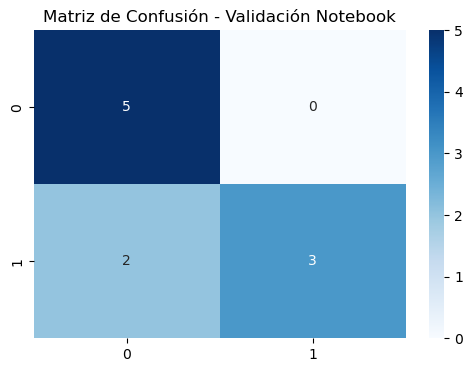

Entrenamiento completado. Accuracy: 0.80
🏃 View run Notebook_Run_20260404_1851 at: http://localhost:5000/#/experiments/1/runs/84ff2dff7063437ca11048eb05722943
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [24]:
# ## 4. Entrenamiento y MLOps
import mlflow
import mlflow.sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from datetime import datetime

# Configuración de MLflow
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Glassdoor_Sentiment_Analysis")

# Carga de datos procesados
df_es = pd.read_csv("../datos/clean_data/processed_spanish.csv")
df_en = pd.read_csv("../datos/clean_data/processed_english.csv")

# Consolidación: 1 para Pros (Positivo), 0 para Cons (Negativo) de los dataframes
datasets = [
    pd.DataFrame({'text': df_es['pros_clean'].dropna(), 'label': 1}),
    pd.DataFrame({'text': df_es['cons_clean'].dropna(), 'label': 0}),
    pd.DataFrame({'text': df_en['pros_clean'].dropna(), 'label': 1}),
    pd.DataFrame({'text': df_en['cons_clean'].dropna(), 'label': 0})
]

full_data = pd.concat(datasets).reset_index(drop=True)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    full_data['text'], full_data['label'], test_size=0.2, random_state=42, stratify=full_data['label']
)

with mlflow.start_run(run_name=f"Notebook_Run_{datetime.now().strftime('%Y%m%d_%H%M')}"):
    
    # 1. Vectorización (TF-IDF)
    vectorizer = TfidfVectorizer(max_features=50, ngram_range=(1, 1))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    # 2. Entrenamiento del Modelo
    model = LogisticRegression(C=1.0, random_state=42, class_weight='balanced')
    model.fit(X_train_tfidf, y_train)
    
    # 3. Predicciones y Métricas
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    # 4. Registro en MLflow (MLOps)
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("tfidf_features", 500)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    
    # Registro del modelo con su firma (input/output schema)
    from mlflow.models.signature import infer_signature
    signature = infer_signature(X_test_tfidf[:5].toarray(), model.predict(X_test_tfidf[:5]))
    
    mlflow.sklearn.log_model(
        sk_model=model, 
        artifact_path="sentiment_model",
        signature=signature,
        input_example=X_test_tfidf[:5].toarray()
    )
    
    # 5. Artefacto Visual: Matriz de Confusión
    fig, ax = plt.subplots(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    plt.title('Matriz de Confusión - Validación Notebook')
    mlflow.log_figure(fig, "confusion_matrix_notebook.png")
    plt.show()

    print(f"Entrenamiento completado. Accuracy: {acc:.2f}")

In [ ]:
# Benchmarking Comparativo
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pysentimiento import create_analyzer
import joblib

# 1. Instanciación de Benchmarks
print("Cargando analizadores externos...")
analyzer_en = SentimentIntensityAnalyzer()
analyzer_es = create_analyzer(task="sentiment", lang="es")

# 2. Carga de nuestro modelo y vectorizador (usando los archivos generados en training/mlops)
try:
    model = joblib.load("../datos/modelos/sentiment_model_global.pkl")
    vectorizer = joblib.load("../datos/modelos/tfidf_vectorizer_global.pkl")
except:
    print("Aviso: No se encontraron modelos locales en /datos/modelos/")

# 3. Lógica de comparación
results_list = []

for lang, file_name in [('ES', 'processed_spanish.csv'), ('EN', 'processed_english.csv')]:
    path = Path(f"../datos/clean_data/{file_name}")
    if not path.exists(): continue
    
    df_eval = pd.read_csv(path)
    print(f"Evaluando {len(df_eval)} registros en {lang}...")

    # Unión de textos para nuestro modelo (Análisis de predominancia)
    texts_combined = df_eval['pros_clean'].fillna('') + " " + df_eval['cons_clean'].fillna('')
    preds_custom = model.predict(vectorizer.transform(texts_combined))

    for i, row in df_eval.iterrows():
        # Lógica para Benchmarks (Normalización a binario 0/1)
        if lang == 'ES':
            # PySentimiento: POS/NEU -> 1, NEG -> 0
            pys_res = analyzer_es.predict(str(row['pros'])).output
            ext_pred = 1 if pys_res in ['POS', 'NEU'] else 0
        else:
            # VADER: Compound >= 0.05 -> 1, < 0 -> 0
            vader_score = analyzer_en.polarity_scores(str(row['pros']))['compound']
            ext_pred = 1 if vader_score >= 0.05 else 0
        
        results_list.append({
            'Idioma': lang,
            'Reseña_Original': row['pros'][:100] + "...",
            'Pred_Nuestro_Modelo': preds_custom[i],
            'Pred_Benchmark': ext_pred
        })

# 4. Resultados Finales
df_bench = pd.DataFrame(results_list)
match_rate = (df_bench['Pred_Nuestro_Modelo'] == df_bench['Pred_Benchmark']).mean() * 100

print(f"\n--- REPORTE DE BENCHMARKING ---")
print(f"Nivel de Coincidencia Global: {match_rate:.2f}%")

# Visualización de las primeras comparaciones
df_bench.sample(n=10).head(10)

Cargando analizadores externos...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3258.86it/s]


Evaluando 19 registros en ES...
Evaluando 6 registros en EN...

--- REPORTE DE BENCHMARKING ---
Nivel de Coincidencia Global: 64.00%


,Idioma,Reseña_Original,Pred_Nuestro_Modelo,Pred_Benchmark
8,ES,Horario\nSueldo \nDinámico\nBuen ambiente de t...,0,1
16,ES,Buen ambiente laboral para todos...,1,1
0,ES,Buen sueldo acorde a la posicion...,1,1
23,EN,Work life balance Company culture Benefits...,1,1
11,ES,"Bonus y descuentos, conocer todos los producto...",1,1
9,ES,"Aprendes rapido, explican muy bien, te da una ...",0,1
13,ES,Buen pago porque te dan viaticos....,0,1
1,ES,"buen ambiente laboral, trabajo no tan pesado...",1,1
22,EN,"Good hourly pay, lots of natural light in the ...",1,1
5,ES,Descuentos a empleados n a...,1,0
